In [10]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [11]:
problems = ["nguyen_9_12"]
seeds = range(5)
algorithms = ["ga", "gomea"]
solvers = ["cgp"]

dfs = []
column_names = ["evaluation", "fitness", "time", "test_accuracy"]
for solver in solvers:
    for algorithm in algorithms:
        for problem in problems:
            for seed in seeds:
                if algorithm == "gomea":
                    for fos in ["U", "RT", "LT", "N1", "N2"]:
                        tmp_df = pd.read_csv(f"../results/{algorithm}_{solver}_{problem}_{fos}_{seed}.csv",
                                             header=None, names=column_names, skiprows=1)
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = f"{algorithm}_{fos}"
                        tmp_df["problem"] = problem
                        tmp_df["solver"] = solver
                        dfs.append(tmp_df)
                else:
                    tmp_df = pd.read_csv(f"../results/{algorithm}_{solver}_{problem}_{seed}.csv", header=None,
                                         names=column_names, skiprows=1)
                    tmp_df["seed"] = seed
                    tmp_df["algorithm"] = algorithm
                    tmp_df["problem"] = problem
                    tmp_df["solver"] = solver
                    dfs.append(tmp_df)
regression_df = pd.concat(dfs, ignore_index=True)
regression_df.head()

,evaluation,fitness,time,test_accuracy,seed,algorithm,problem,solver
0,0,-0.941753,-55.720093,0.51,0,ga,nguyen_9_12,cgp
1,100,-0.941753,-55.720093,0.17,0,ga,nguyen_9_12,cgp
2,200,-0.941753,-55.720093,0.17,0,ga,nguyen_9_12,cgp
3,300,-0.941753,-55.720093,0.17,0,ga,nguyen_9_12,cgp
4,400,-0.941753,-55.720093,0.16,0,ga,nguyen_9_12,cgp


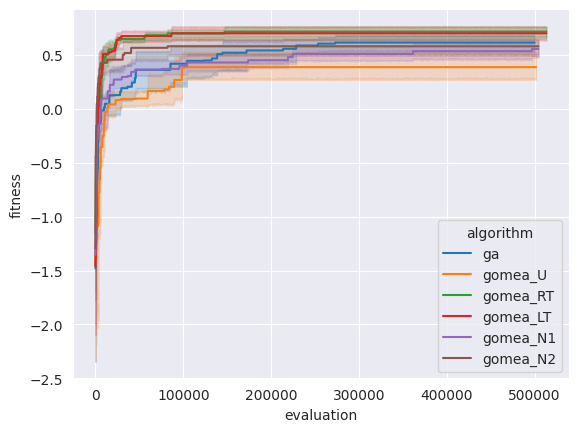

In [12]:
sns.lineplot(
    regression_df,
    x="evaluation",
    y="fitness",
    hue="algorithm",
)
plt.show()

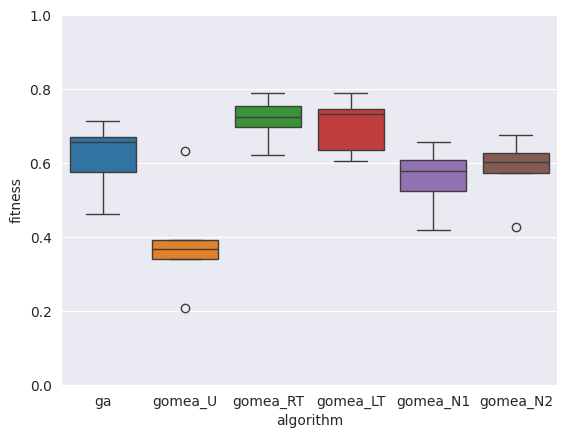

In [13]:
regression_df["max_eval"] = regression_df.groupby("algorithm")["evaluation"].transform("max")
final_regression_df = regression_df[regression_df["evaluation"] == regression_df["max_eval"]].drop(columns="max_eval")
sns.boxplot(
    final_regression_df,
    x="algorithm",
    y="fitness",
    hue="algorithm",
)
plt.ylim(0, 1)
plt.show()

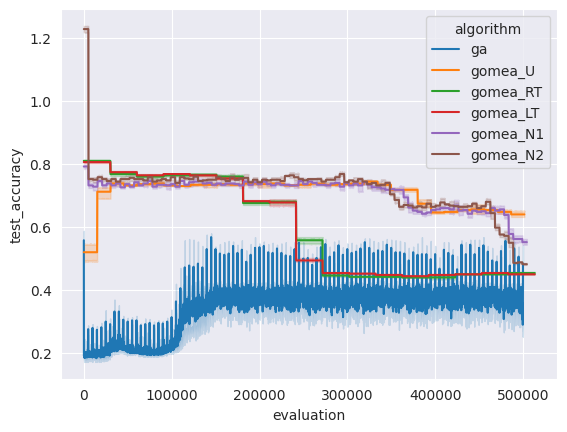

In [14]:
sns.lineplot(
    regression_df,
    x="evaluation",
    y="test_accuracy",
    hue="algorithm",
)
plt.show()

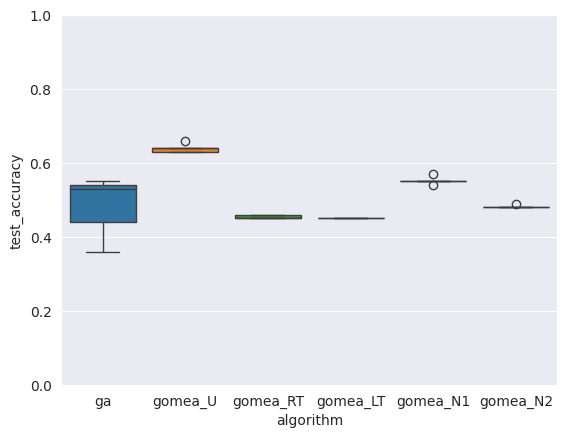

In [15]:
sns.boxplot(
    final_regression_df,
    x="algorithm",
    y="test_accuracy",
    hue="algorithm",
)
plt.ylim(0, 1)
plt.show()